# YOLOX-S & YOLOX-L: OpenVINO Detection

**Flow:** Download models -> select device & model -> infer -> charts

**Models:** YOLOX-S (9M), YOLOX-L (54M) - COCO 80 classes, 640x640

## 1. Install (run once)

In [1]:
!pip install -q openvino openvino-dev opencv-python matplotlib ipywidgets gradio

## 2. Imports and config

In [2]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import cv2
import matplotlib.pyplot as plt
from utils import (
    download_yolox,
    load_yolox_model,
    get_available_devices,
    run_detection_yolox,
    draw_boxes,
    benchmark_latency_ms,
    check_device_latency,
    get_model_size_mb,
    plot_yolox_fp32_fp16_charts,
)

MODEL_DIR = "models_test"
IMAGE_PATH = "media/person.jpg"
TARGET_CLASSES = (0, 2)  # COCO80: person, car
THRESH = 0.3

## 3. Download models (run once, skips if exists)

In [3]:
download_yolox("yolox_s", MODEL_DIR)
download_yolox("yolox_l", MODEL_DIR)

'models_test'

## 4. Select device & model

In [4]:
devices = get_available_devices()
default_dev = "CPU" if "CPU" in devices else (devices[0] if devices else "CPU")
device_dd = widgets.Dropdown(options=devices, value=default_dev, description="Device:")
model_dd = widgets.Dropdown(options=["yolox_s", "yolox_l"], value="yolox_s", description="Model:")
precision_dd = widgets.Dropdown(options=["FP32", "FP16"], value="FP32", description="Precision:")
load_out = widgets.Output()

def _load_yolox(*args):
    global compiled, xml_path
    with load_out:
        load_out.clear_output(wait=True)
        compiled, xml_path = load_yolox_model(MODEL_DIR, model_dd.value, device_dd.value, precision_dd.value)
        print(f"Loaded {model_dd.value} ({precision_dd.value}) on {device_dd.value}")

device_dd.observe(_load_yolox, names="value")
model_dd.observe(_load_yolox, names="value")
precision_dd.observe(_load_yolox, names="value")
display(widgets.HBox([device_dd, model_dd, precision_dd]))
display(load_out)
_load_yolox()

Output()

## 5. Inference

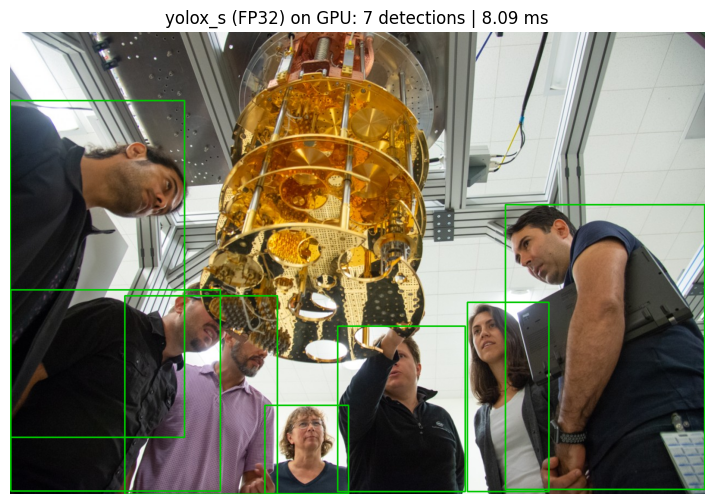

In [9]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

boxes, labels, input_tensor = run_detection_yolox(
    compiled, image, target_classes=TARGET_CLASSES, thresh=THRESH
)
result_img = draw_boxes(image, boxes)
latency_ms = benchmark_latency_ms(compiled, input_tensor, num_iter=50)
check_device_latency(device_dd.value, latency_ms, model_dd.value)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{model_dd.value} ({precision_dd.value}) on {device_dd.value}: {len(boxes)} detections | {latency_ms:.2f} ms")
plt.show()

## 6. Charts: OpenVINO FP32 vs FP16 (by model & device)

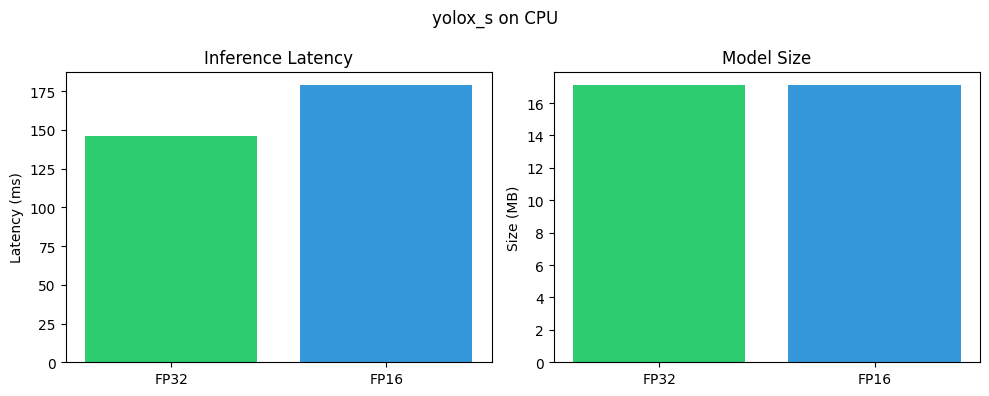

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1000x400 with 2 Axes>', '…

In [6]:
def _update_charts(model, device):
    fig = plot_yolox_fp32_fp16_charts(MODEL_DIR, model, device, IMAGE_PATH, TARGET_CLASSES, THRESH)
    plt.show()

chart_out = widgets.Output()
def _on_chart_change(change):
    with chart_out:
        chart_out.clear_output(wait=True)
        _update_charts(model_dd.value, device_dd.value)
model_dd.observe(_on_chart_change, names="value")
device_dd.observe(_on_chart_change, names="value")
with chart_out:
    _update_charts(model_dd.value, device_dd.value)
display(chart_out)

## 7. Launch Gradio app

In [7]:
from app_gradio import create_demo_yolox
demo = create_demo_yolox(MODEL_DIR)
demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [8]:
# demo.close()